# MS02: Advanced Analytics - Pairplots & Correlation Heatmaps

Cuando nos enfrentamos a un dataset nuevo con múltiples variables numéricas, analizar las relaciones una por una es muy lento. 

En este cuaderno aprenderemos a usar dos de las herramientas más potentes de Seaborn para el **Análisis Exploratorio de Datos (EDA)**:
- **Pairplot:** Para visualizar diagramas de dispersión bivariados de todo el dataset de un solo vistazo.
- **Heatmap:** Para identificar correlaciones matemáticas fuertes entre variables (útil para Machine Learning).

In [6]:
# %pip install seaborn pandas matplotlib numpy
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configurar el estilo
sns.set_theme(style='white')

# Escenario: Base de datos de métricas de clientes de E-commerce
np.random.seed(42)
clientes_data = pd.DataFrame({
    'Membresia': np.random.choice(['Silver', 'Gold', 'Platinum'], size=150),
    'Edad': np.random.normal(35, 10, 150), # Media 35 años
    'Tiempo_App_Minutos': np.random.normal(120, 30, 150),
    'Gasto_Mensual_USD': np.random.normal(500, 150, 150)
})

# Forzamos una correlación positiva artificial para que los gráficos tengan más sentido:
# A mayor tiempo en la app, mayor gasto mensual
clientes_data['Gasto_Mensual_USD'] = clientes_data['Gasto_Mensual_USD'] + (clientes_data['Tiempo_App_Minutos'] * 2.5)

display(clientes_data.head())

,Membresia,Edad,Tiempo_App_Minutos,Gasto_Mensual_USD
0,Platinum,44.035325,66.345105,751.564889
1,Silver,35.190003,130.719136,972.376414
2,Platinum,29.655835,107.564046,880.204567
3,Platinum,20.049461,122.405961,1027.513697
4,Silver,27.107417,93.206392,838.052422


## 1. Pairplot (Matriz de Gráficos de Dispersión)
El `pairplot` cruza todas las variables numéricas entre sí. En la diagonal muestra la distribución de cada variable, y en el resto muestra cómo interactúan. Usar `hue` nos permite ver cómo se comportan los distintos segmentos (Membresías).

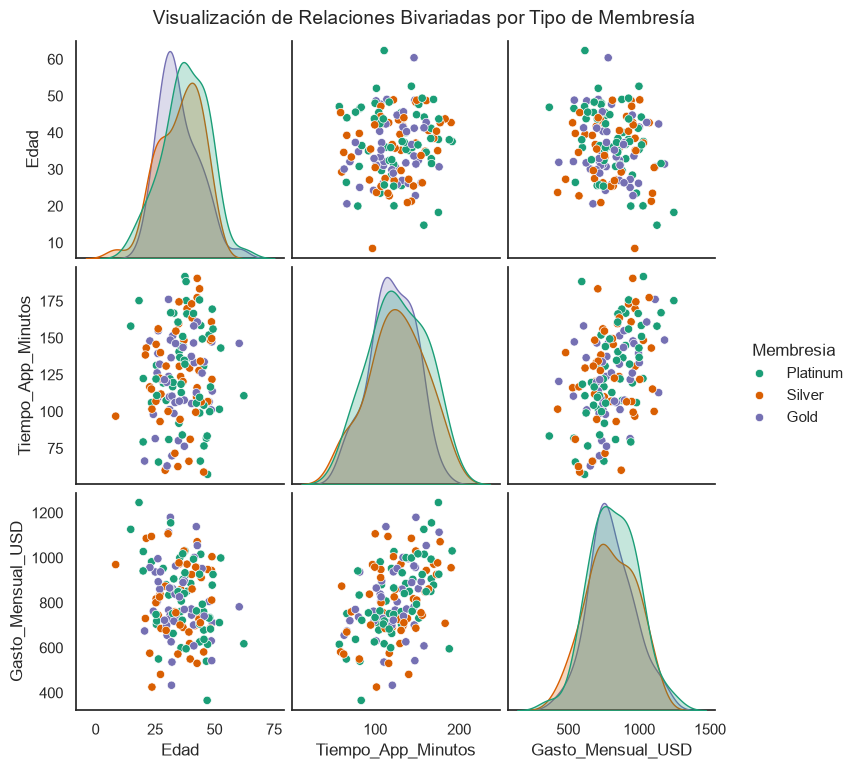

In [7]:
# diag_kind='kde' dibuja curvas de densidad suavizadas en la diagonal principal
g = sns.pairplot(clientes_data, hue='Membresia', palette='Dark2', diag_kind='kde')
g.figure.suptitle('Visualización de Relaciones Bivariadas por Tipo de Membresía', y=1.02, fontsize=14)
plt.show()

## 2. Correlation Heatmaps
La matriz de correlación nos da un valor entre **-1 y 1** que indica la fuerza de la relación entre dos variables.
Dado que la matriz es simétrica (la correlación de A con B es la misma que la de B con A), creamos una **máscara triangular superior** para ocultar la mitad redundante y hacer el gráfico más limpio.

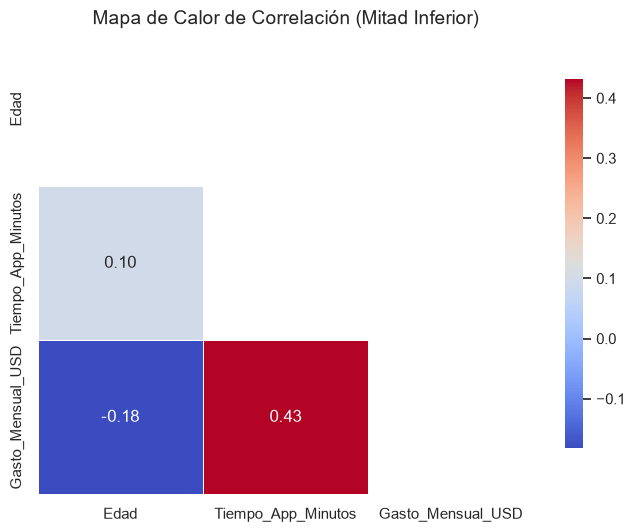

In [9]:
# 1. Calcular la matriz de correlación de Pearson (solo columnas numéricas)
correlation = clientes_data[['Edad', 'Tiempo_App_Minutos', 'Gasto_Mensual_USD']].corr()

# 2. Crear una máscara para ocultar la mitad superior del mapa
# np.ones_like crea una matriz de 1s del mismo tamaño, np.triu aísla el triángulo superior
mask = np.triu(np.ones_like(correlation, dtype=bool))

# 3. Crear el Mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation, 
    annot=True,              # Muestra los valores numéricos
    fmt=".2f",               # Formatea los números a 2 decimales
    cmap='coolwarm',         # Colores: Azul (frío/negativo) a Rojo (caliente/positivo)
    mask=mask,               # Aplica la máscara creada
    linewidths=0.5,          # Espacio entre celdas
    cbar_kws={'shrink': 0.8} # Achica un poco la barra de colores lateral
)

plt.title('Mapa de Calor de Correlación (Mitad Inferior)', fontsize=14)
plt.show()